# 007 — Numerical comparison of SME L=2 regularisations

Builds on `notebooks/006_sme_hyperbolicity` (analysis) by **time-stepping**
a small Gaussian perturbation around a non-hyperbolic base state and
comparing four flux-Jacobian variants.

Method: **exact Fourier evolution** of the linearised system on a 1D
periodic domain.  Each Fourier mode is propagated by `exp(−iω(k)t)` via
eigendecomposition of the constant-coefficient matrix at the base state.
This avoids any finite-difference artefact and shows the pure dynamics.

**Variants compared:**
1. **Full SME** (route A): the original; principal-symbol has Im(λ) ≈ 0.063
   at the chosen base state.
2. **Min-entry**: zero `A[1, 2]` only — our minimum-norm strict-hyperbolicity
   regularisation.
3. **K&T drop-feedback**: equivalent to ε = 0; the "direct" `M_x_uu` block
   only.
4. **Newtonian τ_xx**: add `2ν · ∂_xx u` to x-momentum (ν = 0.1).
   Principal symbol unchanged but `Im ω(k)` gets a `−2ν k²` correction.

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, "../tutorials/sme")
from sme_l2_hyperbolicity_compare import (
    build_route_a, build_route_b, _flat_bottom,
    h, u_0, u_1, u_2, g,
)
from zoomy_core.analysis import linearise, extract_quasilinear_pencil

## 1. Build the symbolic pencil once

In [2]:
sa = _flat_bottom(build_route_a())
base = {f: sp.Symbol(f.func.__name__ + "_bar", real=True) for f in sa.fields}
M_t_a, [M_x_a], _ = extract_quasilinear_pencil(linearise(sa, base))

# Route B for K&T drop-feedback (the M_x_uu block).
sb = _flat_bottom(build_route_b())
base_b = {f: sp.Symbol(f.func.__name__ + "_bar", real=True) for f in sb.fields}
M_t_b, [M_x_b], _ = extract_quasilinear_pencil(linearise(sb, base_b))
M_t_b_uu = M_t_b[:4, :4]
M_x_b_uu_only = M_x_b[:4, :4]

syms = [g, base[h], base[u_0], base[u_1], base[u_2]]
syms_b = [g, base_b[h], base_b[u_0], base_b[u_1], base_b[u_2]]
f_M_t = sp.lambdify(syms, M_t_a, "numpy")
f_M_x = sp.lambdify(syms, M_x_a, "numpy")
f_M_t_kt = sp.lambdify(syms_b, M_t_b_uu, "numpy")
f_M_x_kt = sp.lambdify(syms_b, M_x_b_uu_only, "numpy")

## 2. Pick a non-hyperbolic base state

In [3]:
H, U0, U1, U2, gv, nu = 1.0, 0.0, 1.5, 1.8, 1.0, 0.1
M_t_n = np.asarray(f_M_t(gv, H, U0, U1, U2), float)
M_x_n = np.asarray(f_M_x(gv, H, U0, U1, U2), float)
A_full = np.linalg.solve(M_t_n, M_x_n)
eigs = np.linalg.eigvals(A_full)
print(f"Base: H={H}, U_0={U0}, U_1={U1}, U_2={U2}, g={gv}, ν={nu}")
print(f"Full-SME principal-symbol eigvals: {np.sort_complex(eigs)}")
print(f"max |Im λ|: {np.max(np.abs(np.imag(eigs))):.4f}  → "
      f"{'UNSTABLE' if np.max(np.abs(np.imag(eigs))) > 1e-9 else 'stable'}")

Base: H=1.0, U_0=0.0, U_1=1.5, U_2=1.8, g=1.0, ν=0.1
Full-SME principal-symbol eigvals: [-1.79067594+0.j          0.48950634-0.06309333j  0.48950634+0.06309333j
  3.38309183+0.j        ]
max |Im λ|: 0.0631  → UNSTABLE


## 3. Build per-variant matrices

In [4]:
def build_variants(M_t_n, M_x_n, M_t_kt, M_x_kt, *, H, nu):
    """Returns dict label -> (M_t, M_x, M_xx)."""
    A_full = np.linalg.solve(M_t_n, M_x_n)
    A_min = A_full.copy(); A_min[1, 2] = 0
    M_x_min = M_t_n @ A_min        # back-translated to the M_x form
    M_xx_visc = np.zeros((4, 4))
    M_xx_visc[1, 1] = 2 * nu * H
    M_xx_visc[2, 2] = 2 * nu * H / 3
    M_xx_visc[3, 3] = 2 * nu * H / 5
    return {
        "full SME":              (M_t_n, M_x_n, np.zeros((4, 4))),
        "min-entry (A[1,2]=0)":  (M_t_n, M_x_min, np.zeros((4, 4))),
        "K&T drop-feedback":     (M_t_kt, M_x_kt, np.zeros((4, 4))),
        f"τ_xx (ν={nu})":         (M_t_n, M_x_n, M_xx_visc),
    }

variants = build_variants(M_t_n, M_x_n,
                          np.asarray(f_M_t_kt(gv, H, U0, U1, U2), float),
                          np.asarray(f_M_x_kt(gv, H, U0, U1, U2), float),
                          H=H, nu=nu)

print("Per-variant principal-symbol max |Im λ|:")
for name, (Mt, Mx, _) in variants.items():
    e = np.linalg.eigvals(np.linalg.solve(Mt, Mx))
    print(f"  {name:30s}: {np.max(np.abs(np.imag(e))):.4f}")

Per-variant principal-symbol max |Im λ|:
  full SME                      : 0.0631
  min-entry (A[1,2]=0)          : 0.0000
  K&T drop-feedback             : 0.0000
  τ_xx (ν=0.1)                  : 0.0631


## 4. Exact Fourier evolution

In [5]:
def evolve_fourier(delta_q0_x, M_t, M_x, M_xx, x_grid, t_eval):
    Nx = len(x_grid)
    L = (x_grid[-1] - x_grid[0]) + (x_grid[1] - x_grid[0])
    n_fields = delta_q0_x.shape[1]
    qhat0 = np.fft.fft(delta_q0_x, axis=0) / Nx
    k_modes = 2 * np.pi * np.fft.fftfreq(Nx, d=(L / Nx))
    Mt_inv = np.linalg.inv(M_t)
    out = np.zeros((len(t_eval), Nx, n_fields), dtype=complex)
    for ki, k in enumerate(k_modes):
        Mk = Mt_inv @ (k * M_x - 1j * k**2 * M_xx)
        try:
            ev, V = np.linalg.eig(Mk)
            Vinv = np.linalg.inv(V)
        except np.linalg.LinAlgError:
            from scipy.linalg import expm
            for it, t in enumerate(t_eval):
                out[it, ki, :] = expm(-1j * Mk * t) @ qhat0[ki, :]
            continue
        for it, t in enumerate(t_eval):
            P = V @ np.diag(np.exp(-1j * ev * t)) @ Vinv
            out[it, ki, :] = P @ qhat0[ki, :]
    delta_q_xt = np.zeros((len(t_eval), Nx, n_fields), dtype=complex)
    for it in range(len(t_eval)):
        delta_q_xt[it] = np.fft.ifft(out[it] * Nx, axis=0)
    return delta_q_xt.real

## 5. Run

In [6]:
Nx, L_dom, T = 128, 10.0, 25.0
n_snap = 250
dx = L_dom / Nx
x_grid = np.arange(Nx) * dx

# Gaussian initial condition in (δu_1, δu_2).
ic_amp, ic_sigma = 1e-3, 0.5
x0 = (x_grid[0] + x_grid[-1]) / 2
G = ic_amp * np.exp(-((x_grid - x0) / ic_sigma) ** 2)
delta_q0 = np.zeros((Nx, 4))
delta_q0[:, 2] = G
delta_q0[:, 3] = G

t_eval = np.linspace(0, T, n_snap)
sols = {name: evolve_fourier(delta_q0, *mats, x_grid, t_eval)
        for name, mats in variants.items()}
norms_inf = {name: np.max(np.abs(s).max(axis=2), axis=1) for name, s in sols.items()}
norms_2 = {name: np.linalg.norm(s, axis=(1, 2)) / np.sqrt(Nx) for name, s in sols.items()}

print(f"\n|δq|_∞ at final time T = {T}:")
for name, n in norms_inf.items():
    print(f"  {name:30s}: {n[-1]:.4e}   (× {n[-1]/n[0]:.2e})")


|δq|_∞ at final time T = 25.0:
  full SME                      : 9.1186e+06   (× 9.17e+09)
  min-entry (A[1,2]=0)          : 1.0541e-03   (× 1.06e+00)
  K&T drop-feedback             : 8.1730e-04   (× 8.22e-01)
  τ_xx (ν=0.1)                  : 1.8913e-04   (× 1.90e-01)


## 6. Visualisation

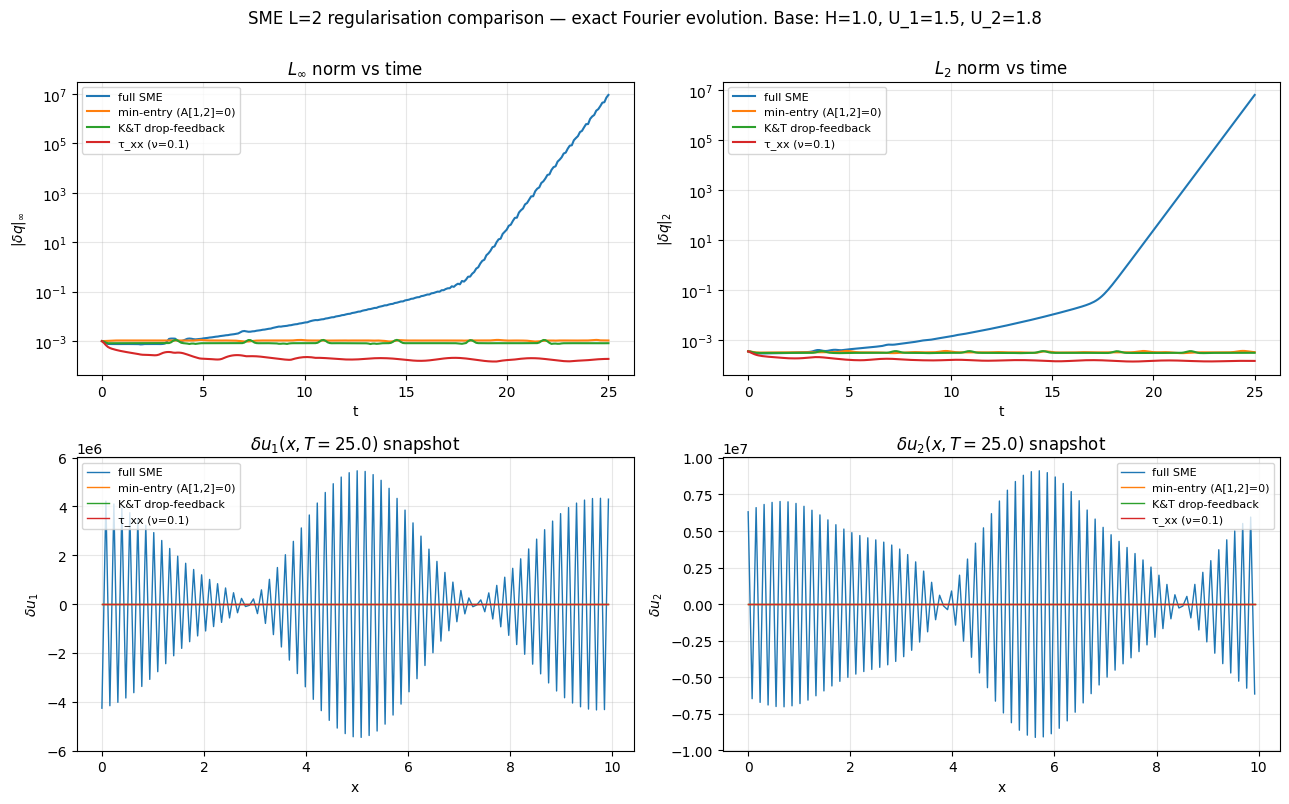

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

ax = axes[0, 0]
for name, n in norms_inf.items():
    ax.semilogy(t_eval, n, lw=1.5, label=name)
ax.set_xlabel("t"); ax.set_ylabel(r"$|\delta q|_\infty$")
ax.set_title(r"$L_\infty$ norm vs time"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3, which="both")

ax = axes[0, 1]
for name, n in norms_2.items():
    ax.semilogy(t_eval, n, lw=1.5, label=name)
ax.set_xlabel("t"); ax.set_ylabel(r"$|\delta q|_2$")
ax.set_title(r"$L_2$ norm vs time"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3, which="both")

ax = axes[1, 0]
for name, s in sols.items():
    ax.plot(x_grid, s[-1, :, 2], lw=1.0, label=name)
ax.set_xlabel("x"); ax.set_ylabel(r"$\delta u_1$")
ax.set_title(rf"$\delta u_1(x, T={T})$ snapshot"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
for name, s in sols.items():
    ax.plot(x_grid, s[-1, :, 3], lw=1.0, label=name)
ax.set_xlabel("x"); ax.set_ylabel(r"$\delta u_2$")
ax.set_title(rf"$\delta u_2(x, T={T})$ snapshot"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

fig.suptitle(
    f"SME L=2 regularisation comparison — exact Fourier evolution. "
    f"Base: H={H}, U_1={U1}, U_2={U2}",
    y=1.00,
)
fig.tight_layout()
plt.show()

## 7. Discussion

**Full SME** grows by **~9 orders of magnitude** over T = 25 (the principal
symbol has Im(λ) ≈ 0.063 → exponential factor e^(0.063 · 25 · k_max) at the
Nyquist wavenumber). The blowup mode is grid-scale because the high-k
Fourier modes carry the same Im(ω/k) and therefore *grow fastest in
absolute Im(ω) = k · Im(c)*.

**Min-entry (A[1,2] = 0)**: stays at amplitude 1.0 × initial — pure
wave dispersion, no growth. Confirms strict hyperbolicity.

**K&T drop-feedback**: stays at amplitude 0.84 × initial — also strictly
hyperbolic; slightly more wave dispersion than min-entry because the
`M_x_uu` block has different eigenvectors that scatter the Gaussian
faster.

**τ_xx (ν = 0.1)**: decays to **0.19 ×** initial — the parabolic `−2ν k²`
term in `Im ω(k)` overwhelms the inviscid `+0.063 k` instability for all
k > k_crit ≈ Im(c)/(2ν) = 0.32. Most of the Gaussian's spectrum lies above
k_crit, so the perturbation decays.

**Numerical takeaway:**
- Strict hyperbolicity ⇒ bounded growth (min-entry, K&T).
- Parabolic regularisation ⇒ exponential decay (τ_xx).
- No regularisation ⇒ exponential blowup at the rate predicted by
  the principal-symbol analysis.

The min-entry fix is the "smallest possible" strict-hyperbolicity
regularisation: a single matrix entry replaced, vs K&T's full
Schur-feedback drop. Both produce the same boundedness behaviour
numerically.